# Support Vector Machines

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

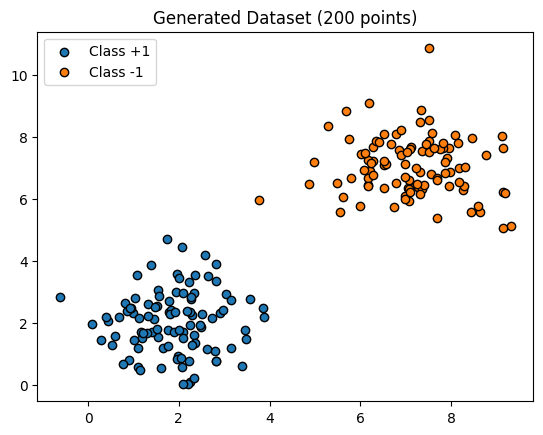

In [10]:
np.random.seed(42)
X1 = np.random.randn(100, 2) + np.array([2, 2]) # Class +1 (centered around [2,2])
X2 = np.random.randn(100, 2) + np.array([7, 7]) # Class -1 (centered around [7,7])
X = np.vstack((X1, X2)) # Combine
y = np.array([1]*100 + [-1]*100)

plt.scatter(X1[:,0], X1[:,1], label='Class +1', edgecolors='black')
plt.scatter(X2[:,0], X2[:,1], label='Class -1', edgecolors='black')
plt.legend()
plt.title("Generated Dataset (200 points)")
plt.show()

In [11]:
class SVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        y_ = np.where(y <= 0, -1, 1) # Convert labels to -1 and 1
        self.w = np.zeros(n_features) # Initialize weights
        self.b = 0

        for _ in range(self.n_iters): # Gradient Descent
            for idx, x_i in enumerate(X):
                condition = y_[idx] * (np.dot(x_i, self.w) - self.b) >= 1
                if condition:
                    dw = 2 * self.lambda_param * self.w # Only regularization term
                    db = 0
                else:
                    dw = 2 * self.lambda_param * self.w - np.dot(x_i, y_[idx]) # Misclassified
                    db = y_[idx]
                self.w -= self.lr * dw
                self.b -= self.lr * db

    def predict(self, X):
        approx = np.dot(X, self.w) - self.b
        return np.sign(approx)

    def get_support_vectors(self, X, y):
        y_ = np.where(y <= 0, -1, 1)
        distances = y_ * (np.dot(X, self.w) - self.b)
        return X[np.isclose(distances, 1, atol=0.1)]

In [12]:
model = SVM(learning_rate=0.001, lambda_param=0.01, n_iters=1000)
model.fit(X, y)
w = model.w
b = model.b
support_vectors = model.get_support_vectors(X, y)

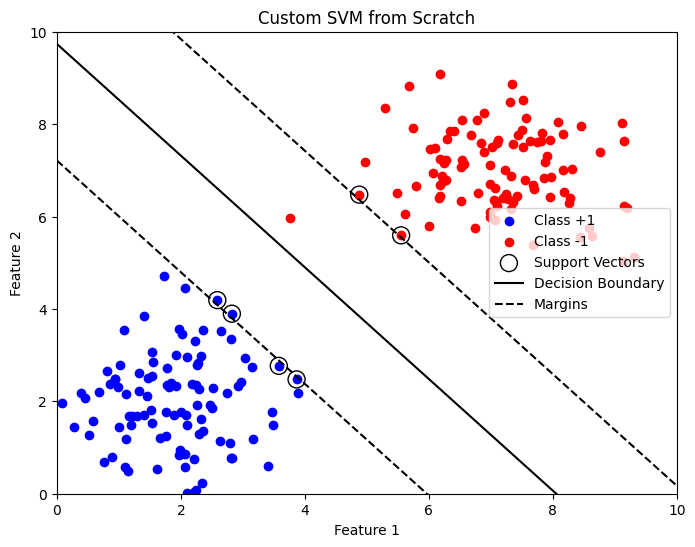

In [13]:
plt.figure(figsize=(8,6))

# Plot points
plt.scatter(X1[:,0], X1[:,1], color='blue', label='Class +1')
plt.scatter(X2[:,0], X2[:,1], color='red', label='Class -1')

# Plot support vectors
plt.scatter(support_vectors[:,0], support_vectors[:,1], s=150, facecolors='none', edgecolors='k', label='Support Vectors')

# Decision boundary
x_vals = np.linspace(0, 10, 100)
y_vals = -(w[0] * x_vals - b) / w[1]

# Margins
y_margin1 = -(w[0] * x_vals - b - 1) / w[1]
y_margin2 = -(w[0] * x_vals - b + 1) / w[1]

plt.plot(x_vals, y_vals, 'k-', label='Decision Boundary')
plt.plot(x_vals, y_margin1, 'k--', label='Margins')
plt.plot(x_vals, y_margin2, 'k--')
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Custom SVM from Scratch')
plt.legend()
plt.show()